In [1]:
import os
import gc
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

In [2]:
df = pd.read_csv("FINAL_cleaned_annotations_RESOLVED1.csv")

In [3]:
texts = df["cleaned_text"].astype(str)
labels = df["final_sentiment"]

In [4]:
le = LabelEncoder()
y = le.fit_transform(labels)
num_labels = len(le.classes_)

In [5]:
# DATA SPLIT (80-20 then 80-20 logic)
train_texts_full, test_texts, train_labels_full, test_labels = train_test_split(
    df["cleaned_text"].astype(str), y, test_size=0.2, random_state=42, stratify=y
)

# Inner split: 80% train, 20% validation (of the 80% training pool)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full, test_size=0.2, random_state=42, stratify=train_labels_full
)

print(f"Training size: {len(train_texts)}")
print(f"Validation size: {len(val_texts)}")
print(f"Test size: {len(test_texts)}")

Training size: 5150
Validation size: 1288
Test size: 1610


In [6]:
# TOKENIZATION (XLM-RoBERTa Base)
model_checkpoint = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512
    )

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)
test_encodings = tokenize(test_texts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [7]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [8]:
# GRID SEARCH CONFIGURATION
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [9]:
def run_experiment(batch_size, lr, epochs=10):
    print(f"\nRunning Experiment: batch={batch_size} | lr={lr}")
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_labels
    )

    training_args = TrainingArguments(
        output_dir=f"./grid_xlmr_bs{batch_size}_lr{lr}",
        eval_strategy="epoch",
        save_strategy="epoch",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=50,
        fp16=True,
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()
    metrics = trainer.evaluate()

    f1 = metrics["eval_f1"]
    loss = metrics["eval_loss"]

    # Memory cleanup
    del trainer, model
    torch.cuda.empty_cache()
    gc.collect()

    return f1, loss

In [10]:
# Hyperparameter Grid
batch_sizes = [16, 32]
learning_rates = [2e-5, 3e-5, 5e-5]

results = []
best_f1 = 0
best_params = None

for bs in batch_sizes:
    for lr in learning_rates:
        f1, loss = run_experiment(bs, lr, epochs=10)
        results.append({
            "batch_size": bs,
            "learning_rate": lr,
            "loss": loss,
            "f1": f1
        })
        if f1 > best_f1:
            best_f1 = f1
            best_params = (bs, lr)

best_bs, best_lr = best_params
print(f"\nBEST CONFIG: {best_params} with F1: {round(best_f1, 4)}")


Running Experiment: batch=16 | lr=2e-05


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.615521,0.538909,0.796584,0.797067
2,0.413678,0.397572,0.847826,0.849343
3,0.318349,0.376664,0.862578,0.863387
4,0.250837,0.385906,0.872671,0.872681
5,0.228921,0.466760,0.885093,0.885656


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


BEST CONFIG: (16, 3e-05) with F1: 0.8755


In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1", ascending=False)

print(results_df)

   batch_size  learning_rate      loss        f1
1          16        0.00003  0.346872  0.875465
4          32        0.00003  0.380559  0.874030
3          32        0.00002  0.366799  0.869716
0          16        0.00002  0.376708  0.864948
5          32        0.00005  0.408866  0.858012
2          16        0.00005  0.514862  0.808285


In [12]:
# Final Model Training
print("\nTraining FINAL XLM-RoBERTa model...")
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels
)

training_args = TrainingArguments(
    output_dir="./best_xlmr_model",

    eval_strategy="epoch",
    save_strategy="epoch",

    num_train_epochs=10,

    per_device_train_batch_size=best_bs,
    per_device_eval_batch_size=best_bs,

    learning_rate=best_lr,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    logging_steps=50,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

trainer.train()


Training FINAL XLM-RoBERTa model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.600119,0.512193,0.809006,0.809172
2,0.414188,0.419919,0.846273,0.847466
3,0.288602,0.457833,0.868012,0.868916
4,0.214868,0.301349,0.887422,0.887538
5,0.177049,0.501916,0.888199,0.888805
6,0.157755,0.506070,0.899068,0.899242
7,0.052367,0.669519,0.893634,0.893530
8,0.094947,0.603937,0.900621,0.901062
9,0.028914,0.761373,0.887422,0.887530


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2898, training_loss=0.2637604194274847, metrics={'train_runtime': 1706.8896, 'train_samples_per_second': 30.172, 'train_steps_per_second': 1.886, 'total_flos': 1.21953069116928e+16, 'train_loss': 0.2637604194274847, 'epoch': 9.0})

In [13]:
# Evaluation and Plotting
pred_test = trainer.predict(test_dataset)
preds_test = np.argmax(pred_test.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(test_labels, preds_test, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.89      0.88       489
     neutral       0.84      0.87      0.85       564
    positive       0.95      0.91      0.93       557

    accuracy                           0.89      1610
   macro avg       0.89      0.89      0.89      1610
weighted avg       0.89      0.89      0.89      1610



In [14]:
# Duo Score calculation
test_df = df.iloc[test_texts.index].copy()
test_df["predicted_sentiment"] = le.inverse_transform(preds_test)

counts = (
    test_df
    .groupby(["duo", "predicted_sentiment"])
    .size()
    .unstack(fill_value=0)
)

In [15]:
# Sentiment Score logic
counts["score"] = (counts["positive"] - counts["negative"]) / \
                 (counts["positive"] + counts["negative"])

exp_scores = np.exp(counts["score"])
counts["percentage"] = exp_scores / exp_scores.sum() * 100

print("\nDuo Prediction Results:")
print(counts.sort_values("percentage", ascending=False))


Duo Prediction Results:
predicted_sentiment  negative  neutral  positive     score  percentage
duo                                                                   
RaWi                       85      167       167  0.325397   31.786869
BreKa                      89      147       162  0.290837   30.707076
CharEs                    133      144       141  0.029197   23.637952
AzVer                     185      129        61 -0.504065   13.868103


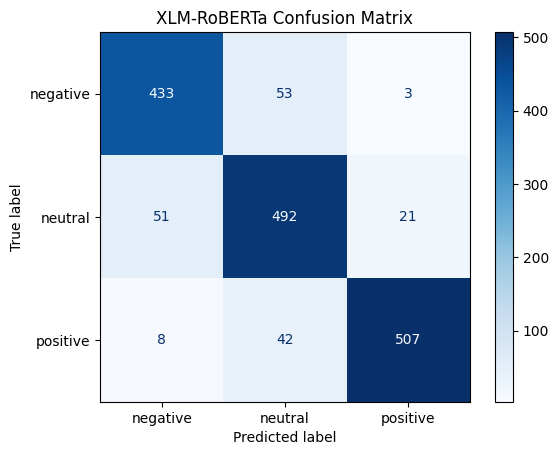

In [16]:
# Confusion Matrix
cm = confusion_matrix(test_labels, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("XLM-RoBERTa Confusion Matrix")
plt.show()

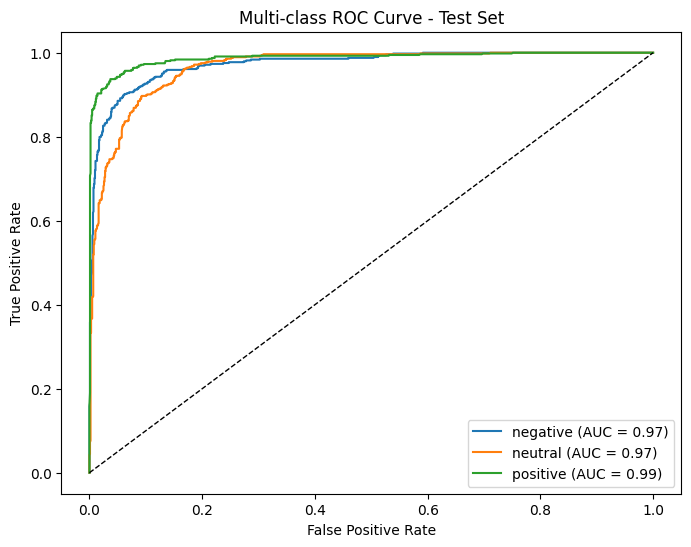

In [17]:
y_test_bin = label_binarize(test_labels, classes=range(num_labels))
y_score = pred_test.predictions

plt.figure(figsize=(8,6))
for i in range(num_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.show()